In [19]:
from fourier_paper_reproduction_2023_09_28 import default_config, output_dir
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from misc_utils import read_jsonl_to_df, keep_serializable

from itertools import product
from pathlib import Path

import fire
import jsonlines
import numpy as np
from loguru import logger

from fourier_paper_reproduction import (
    accuracy,
    get_ipr,
    how_many_terms_to_achieve,
    how_many_terms_to_achieve_relative_weight,
    rel_fourier_weight_in_largest_terms,
    sign_overlap,
)
from fourier_supervised_cleanroom import (
    amplitude_median_bin_signal,
    amplitude_prob_median_bin_signal,
    fit_fourier_series,
    ground_state_signal,
    sign_signal,
)
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from spin_lattices import KagomeLattice, SquareLattice, TriangularLattice
from misc_utils import convert_column_to as to

In [20]:
df = read_jsonl_to_df(output_dir.glob('*/results.jsonl')).fillna(keep_serializable(default_config))

In [21]:
df.sort_values("n_spins")

,J2,lattice,n_spins,terms_score_threshold,relweight_corresponding_to_terms,terms_relweight_threshold,iipr,scorer,signal,threshold
855,0.25,KagomeLattice2x2,12,39,0.347398,467,206.698836,accuracy,amplitude_median_bin_signal,0.90
1147,0.50,KagomeLattice2x2,12,1,0.137734,67,25.423877,accuracy,amplitude_prob_median_bin_signal,0.50
1146,0.50,KagomeLattice2x2,12,1,0.137734,2,25.423877,accuracy,amplitude_prob_median_bin_signal,0.20
1145,0.50,KagomeLattice2x2,12,1,0.137734,1,25.423877,accuracy,amplitude_prob_median_bin_signal,0.02
1144,0.50,KagomeLattice2x2,12,1532,0.983762,1769,25.423877,sign_overlap,amplitude_prob_median_bin_signal,0.99
...,...,...,...,...,...,...,...,...,...,...
532,0.00,KagomeLattice2x4,24,1,0.161180,2,19.226969,accuracy,sign_signal,0.20
533,0.00,KagomeLattice2x4,24,1,0.161180,2074,19.226969,accuracy,sign_signal,0.50
534,0.00,KagomeLattice2x4,24,1,0.161180,1131750,19.226969,accuracy,sign_signal,0.80
535,0.00,KagomeLattice2x4,24,1,0.161180,3815987,19.226969,accuracy,sign_signal,0.90


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


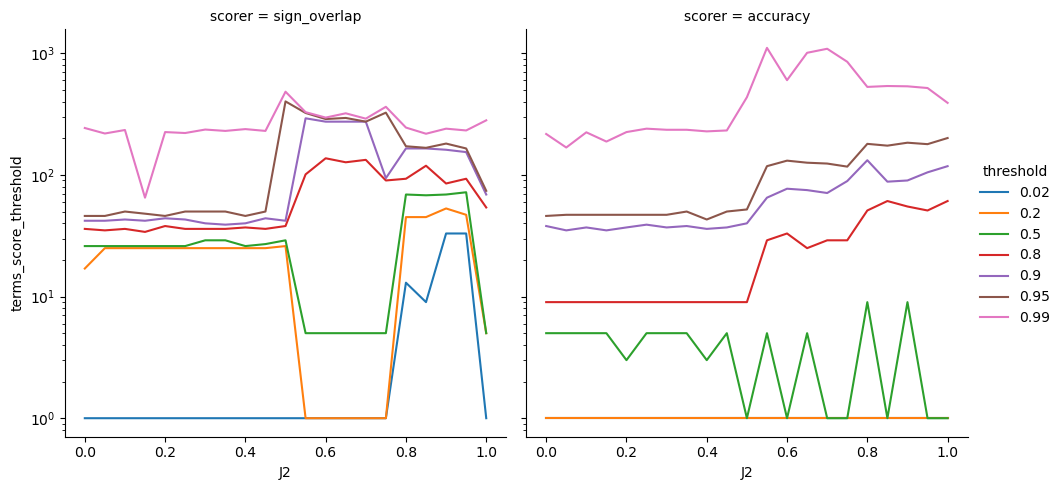

In [22]:
sns.relplot(
    df.query(
        'lattice == "KagomeLattice2x2"  and signal == "amplitude_median_bin_signal"'
    ).pipe(to(str, ["threshold"])),
    x="J2",
    y="terms_score_threshold",
    hue="threshold",
    kind="line",
    col="scorer",
).set(yscale="log")

/tmp/nix-shell.bmJ5hO/ipykernel_2053784/2368586117.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


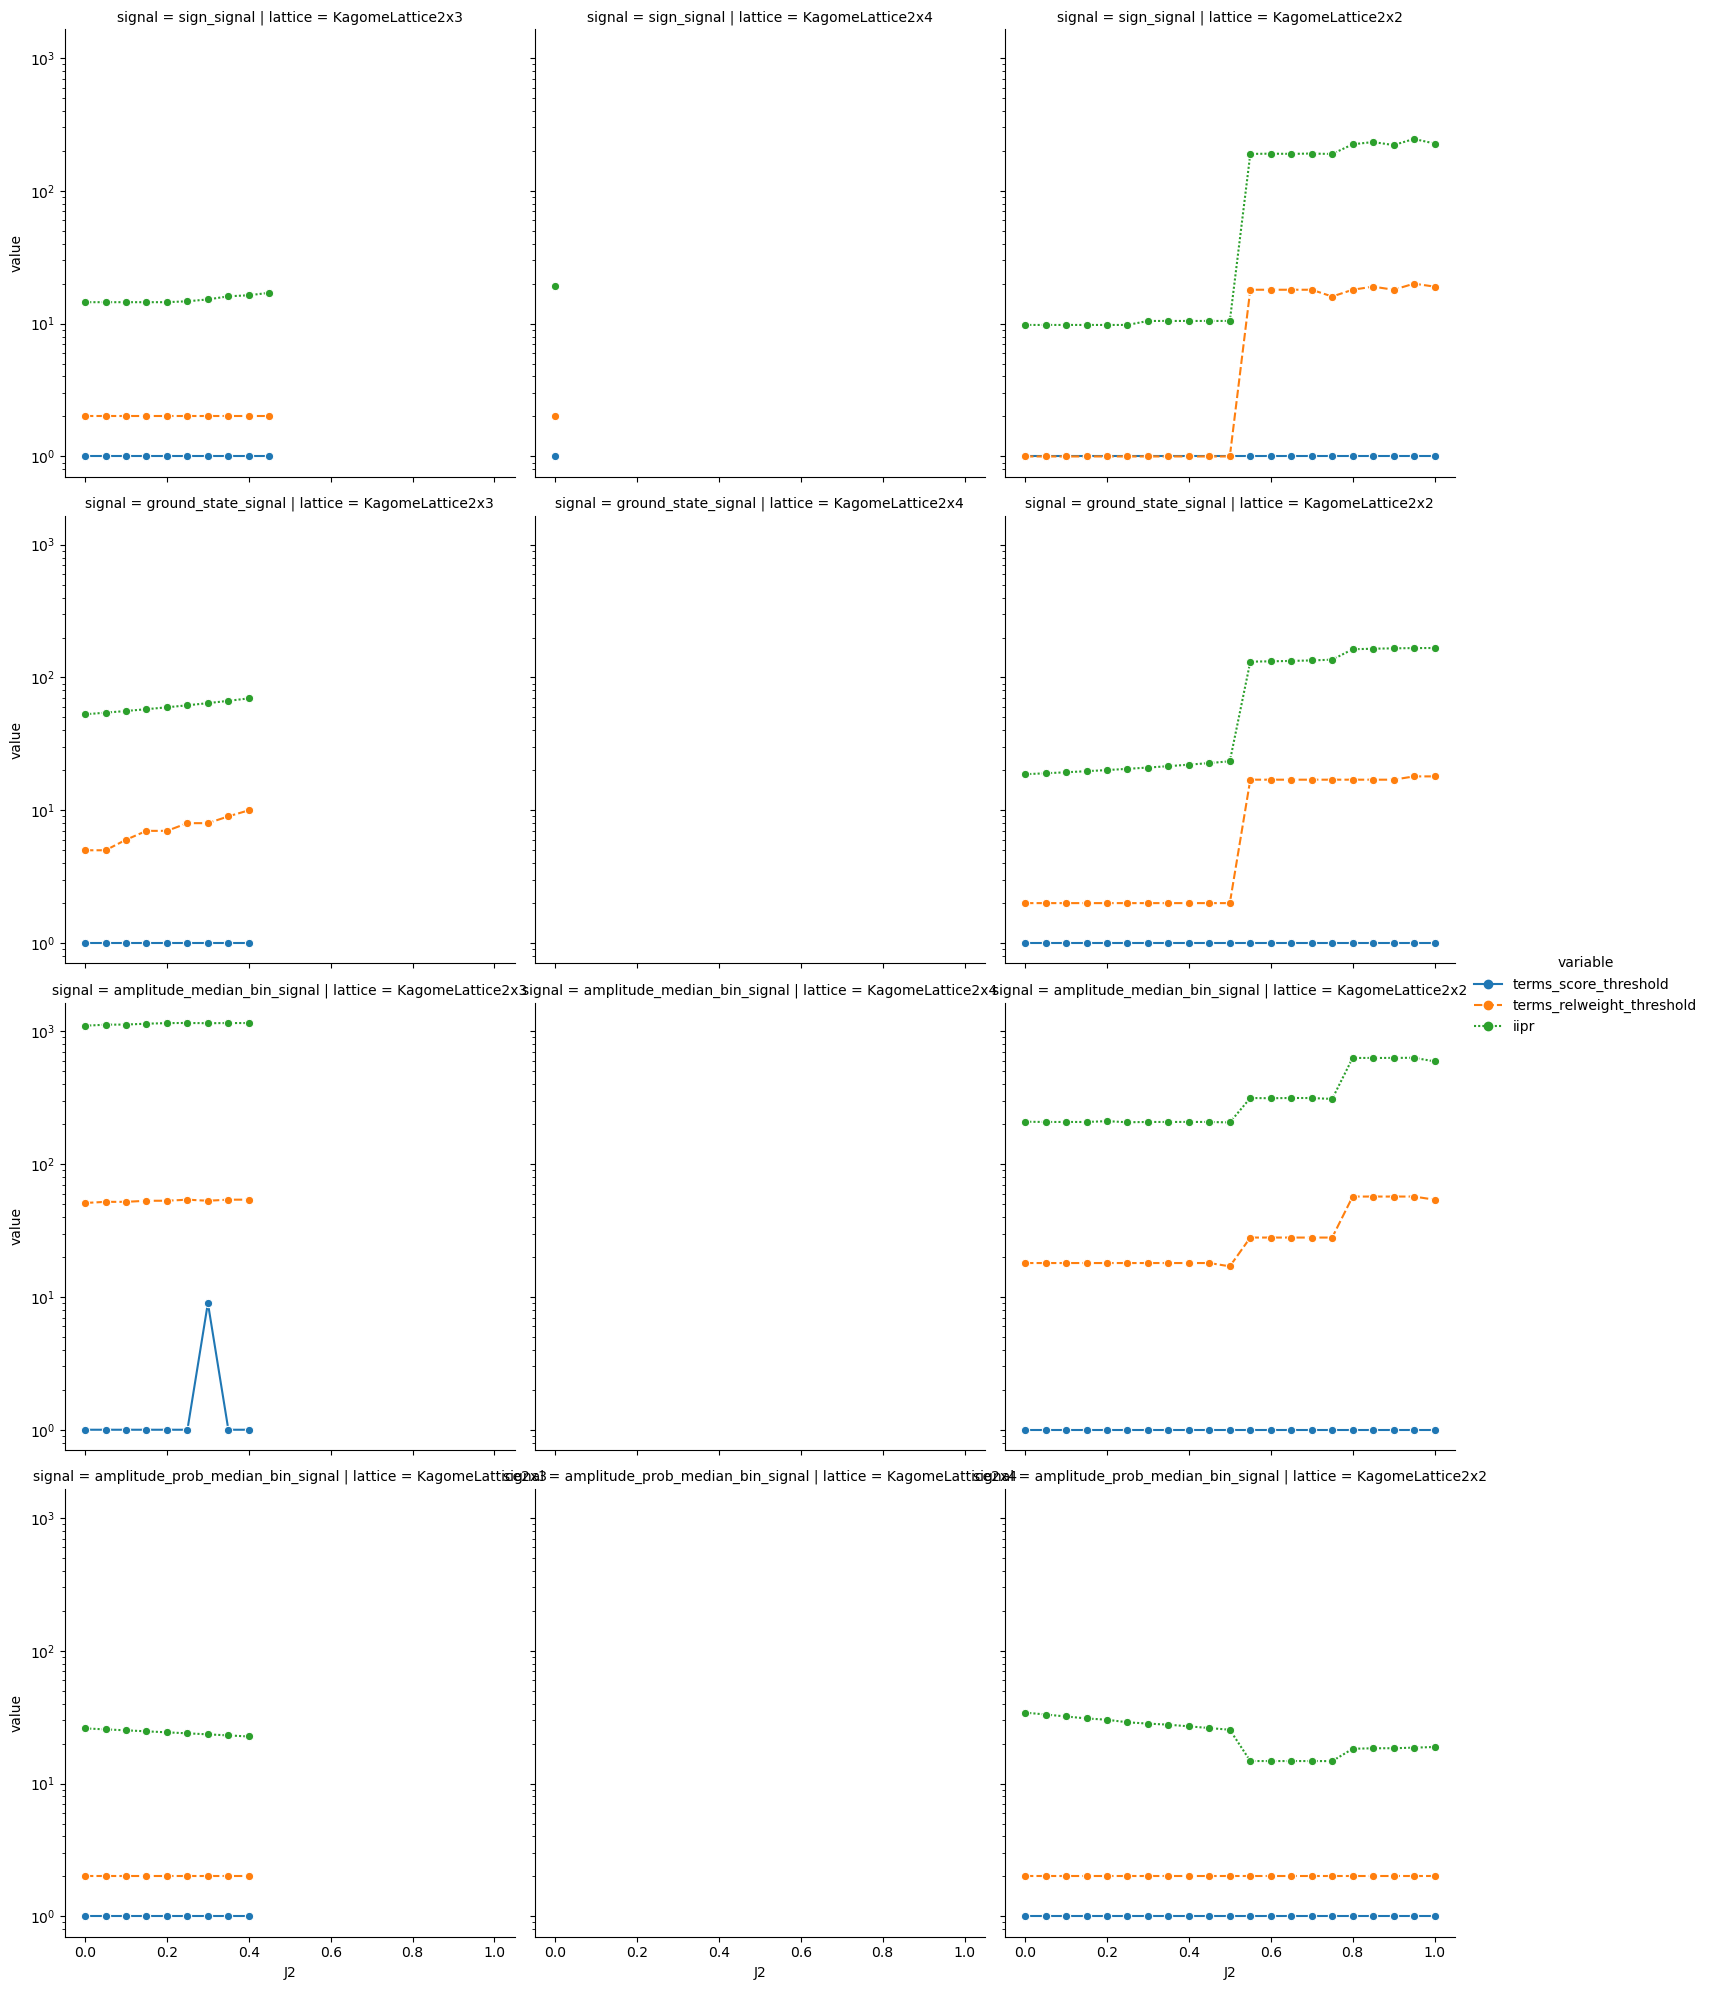

In [24]:
sns.relplot(
    df.query('threshold == 0.2 and scorer == "accuracy"').melt(
        id_vars=["J2", "lattice", "n_spins", "threshold", "scorer", "signal"],
        value_vars=["terms_score_threshold", "terms_relweight_threshold", "iipr"],
    ),
    x="J2",
    y="value",
    hue="variable",
    col='lattice',
    row='signal',
    kind='line',
    markers=['o'],
    style='variable',

).set(yscale='log')